# Nostradamus 1h

Descargando datos para el intervalo 1h
Datos descargados correctamente
1/1 [==============================] - 0s 37ms/step


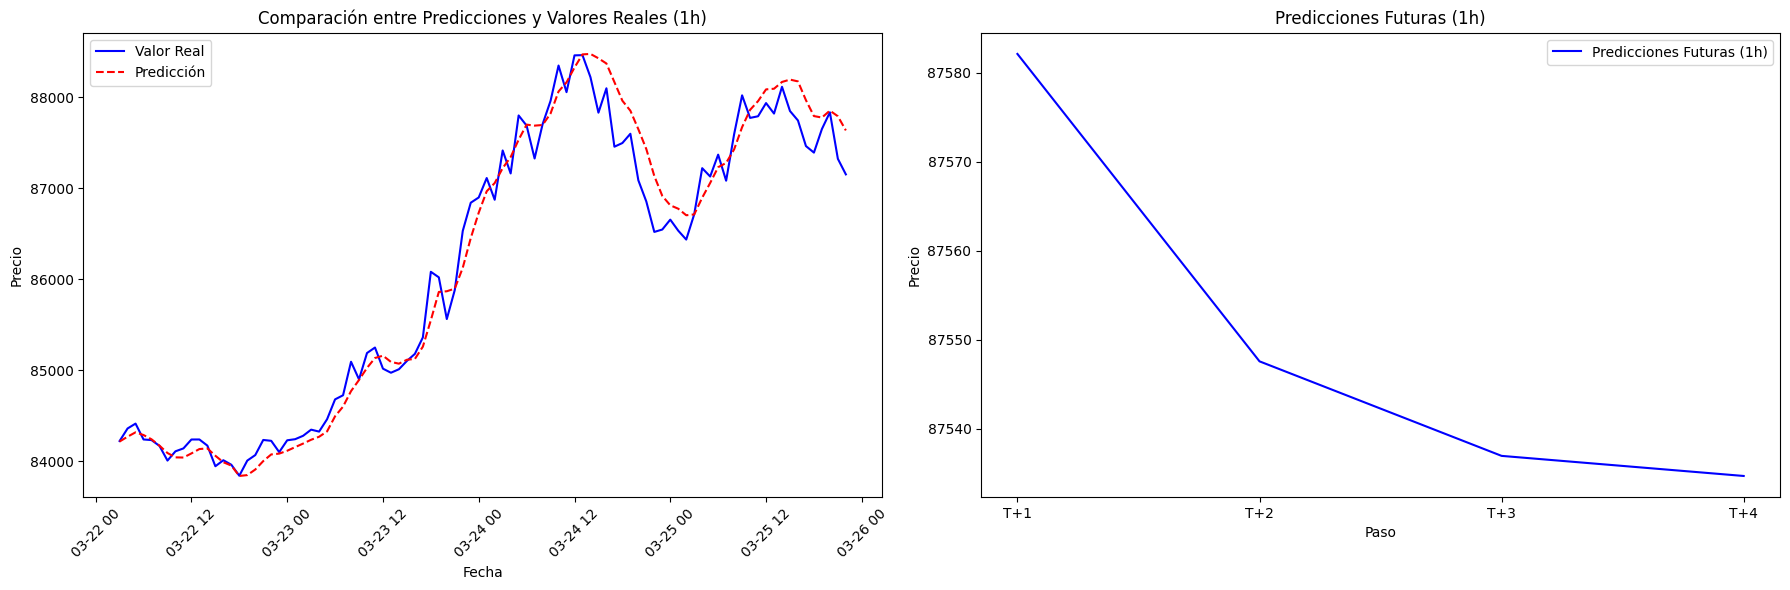

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tvDatafeed import TvDatafeed, Interval

# Inicializar conexión a TradingView
tv = TvDatafeed()

# Función para crear secuencias
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Función para predicciones futuras
def predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler):
    last_sequence = data_scaled[-seq_length:]
    future_predictions = []
    
    for _ in range(num_predictions):
        input_sequence = np.reshape(last_sequence, (1, seq_length, num_features))
        next_prediction_scaled = model.predict(input_sequence)[0, 0]
        next_prediction_scaled = max(0, min(1, next_prediction_scaled))
        
        future_predictions.append(next_prediction_scaled)
        next_sequence = np.hstack((next_prediction_scaled, last_sequence[-1, 1:]))
        last_sequence = np.vstack((last_sequence[1:], next_sequence))
    
    future_predictions_actual = scaler.inverse_transform(
        np.hstack((np.array(future_predictions).reshape(-1, 1), np.zeros((num_predictions, num_features - 1)))))[:, 0]
    
    return pd.DataFrame({'Paso': [f'T+{i+1}' for i in range(num_predictions)], 'Precio': future_predictions_actual})

# Cargar el modelo LSTM
model_path = 'D:/YOP/web_page_geosierra/lstm_price_prediction_model.h5'
try:
    model = load_model(model_path)
except FileNotFoundError:
    raise FileNotFoundError(f"El modelo {model_path} no fue encontrado.")

# Descargar datos de TradingView (BTCUSDT - intervalo 1 hora)
try:
    print("Descargando datos para el intervalo 1h")
    btcusdt_binance_data = tv.get_hist(symbol='BTCUSDT', exchange='BINANCE', interval=Interval.in_1_hour, n_bars=506)
    
    if btcusdt_binance_data is None:
        raise ValueError("No se pudieron obtener datos para el intervalo 1h")
    
    # Convertir datos a DataFrame
    df = pd.DataFrame(btcusdt_binance_data)
    df.reset_index(inplace=True)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    print("Datos descargados correctamente")
    
except Exception as e:
    print(f"Error al descargar los datos: {e}")

# Procesar los datos descargados
df = df[['datetime', 'open', 'high', 'low', 'close', 'volume']].dropna()
data_numeric = df[['open', 'high', 'low', 'close', 'volume']]

# Escalar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_numeric)

# Crear secuencias para entrenamiento y test
seq_length = 50
x, y = create_sequences(data_scaled, seq_length)

train_size = int(len(x) * 0.8)
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:], y[train_size:]

num_features = data_numeric.shape[1]
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], num_features))

# Predicciones en el conjunto de prueba
y_pred = model.predict(x_test)
y_pred = y_pred[:len(y_test)]

# Desescalar las predicciones y los valores reales
y_test_actual = scaler.inverse_transform(
    np.hstack((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], num_features - 1)))))[:, 0]

y_pred_actual = scaler.inverse_transform(
    np.hstack((y_pred.reshape(-1, 1), np.zeros((y_pred.shape[0], num_features - 1)))))[:, 0]

# Guardar las predicciones
predictions_df = pd.DataFrame({
    'Fecha': df['datetime'].iloc[train_size + seq_length: train_size + seq_length + len(y_pred)].values,
    'Real': y_test_actual,
    'Predicción': y_pred_actual
})

# Predicciones futuras
num_predictions = 4  # Predecir 4 velas para 1h
future_predictions_df = predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler)

# Graficar resultados
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Comparación entre valores reales y predicciones
axs[0].plot(predictions_df['Fecha'], predictions_df['Real'], label='Valor Real', color='blue')
axs[0].plot(predictions_df['Fecha'], predictions_df['Predicción'], label='Predicción', color='red', linestyle='--')
axs[0].set_title(f'Comparación entre Predicciones y Valores Reales (1h)')
axs[0].set_xlabel('Fecha')
axs[0].set_ylabel('Precio')
axs[0].legend()
axs[0].tick_params(axis='x', rotation=45)

# Predicciones futuras
axs[1].plot(future_predictions_df['Paso'], future_predictions_df['Precio'], label=f'Predicciones Futuras (1h)', color='blue')
axs[1].set_title(f'Predicciones Futuras (1h)')
axs[1].set_xlabel('Paso')
axs[1].set_ylabel('Precio')
axs[1].legend()

plt.tight_layout()
plt.show()


# Nostradamus 15m, 1h, 4h

Descargando datos para el intervalo Interval.in_1_hour
Datos descargados correctamente
1/1 [==============================] - 0s 74ms/step
Descargando datos para el intervalo Interval.in_4_hour
Datos descargados correctamente
1/1 [==============================] - 0s 68ms/step
Descargando datos para el intervalo Interval.in_15_minute
Datos descargados correctamente
1/1 [==============================] - 0s 57ms/step


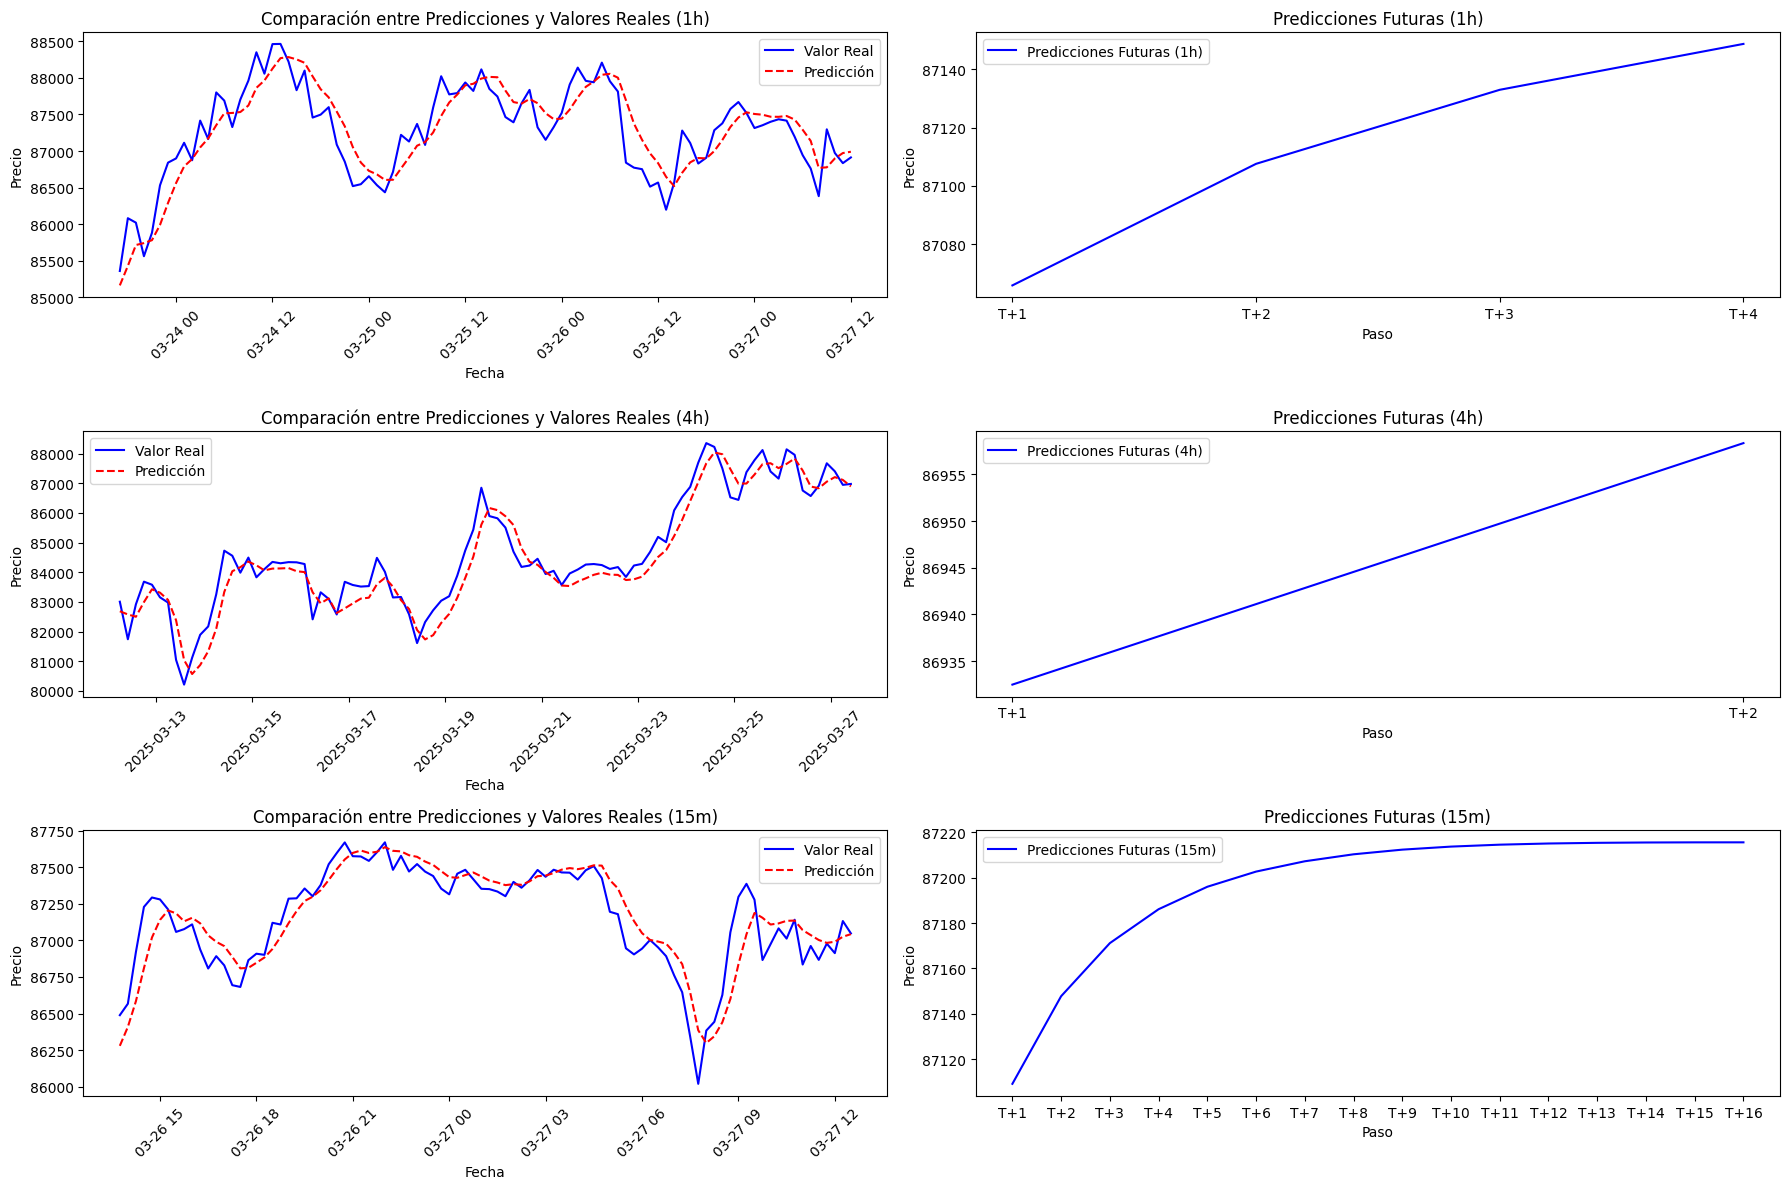

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tvDatafeed import TvDatafeed, Interval

# Inicializar conexión a TradingView
tv = TvDatafeed()

# Función para crear secuencias
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Función para predicciones futuras
def predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler):
    last_sequence = data_scaled[-seq_length:]
    future_predictions = []
    
    for _ in range(num_predictions):
        input_sequence = np.reshape(last_sequence, (1, seq_length, num_features))
        next_prediction_scaled = model.predict(input_sequence)[0, 0]
        next_prediction_scaled = max(0, min(1, next_prediction_scaled))
        
        future_predictions.append(next_prediction_scaled)
        next_sequence = np.hstack((next_prediction_scaled, last_sequence[-1, 1:]))
        last_sequence = np.vstack((last_sequence[1:], next_sequence))
    
    future_predictions_actual = scaler.inverse_transform(
        np.hstack((np.array(future_predictions).reshape(-1, 1), np.zeros((num_predictions, num_features - 1)))))[:, 0]
    
    return pd.DataFrame({'Paso': [f'T+{i+1}' for i in range(num_predictions)], 'Precio': future_predictions_actual})

# Cargar el modelo LSTM
model_path = 'D:/YOP/web_page_geosierra/lstm_price_prediction_model.h5'
try:
    model = load_model(model_path)
except FileNotFoundError:
    raise FileNotFoundError(f"El modelo {model_path} no fue encontrado.")

# Función para descargar y procesar datos de TradingView para un intervalo dado
def download_and_process_data(interval, num_predictions, seq_length=50):
    try:
        print(f"Descargando datos para el intervalo {interval}")
        btcusdt_binance_data = tv.get_hist(symbol='BTCUSDT', exchange='BINANCE', interval=interval, n_bars=506)
        
        if btcusdt_binance_data is None:
            raise ValueError(f"No se pudieron obtener datos para el intervalo {interval}")
        
        # Convertir datos a DataFrame
        df = pd.DataFrame(btcusdt_binance_data)
        df.reset_index(inplace=True)
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        print("Datos descargados correctamente")
        
        # Procesar los datos descargados
        df = df[['datetime', 'open', 'high', 'low', 'close', 'volume']].dropna()
        data_numeric = df[['open', 'high', 'low', 'close', 'volume']]

        # Escalar los datos
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_scaled = scaler.fit_transform(data_numeric)

        # Crear secuencias
        x, y = create_sequences(data_scaled, seq_length)

        train_size = int(len(x) * 0.8)
        x_train, y_train = x[:train_size], y[:train_size]
        x_test, y_test = x[train_size:], y[train_size:]

        num_features = data_numeric.shape[1]
        x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], num_features))

        # Predicciones en el conjunto de prueba
        y_pred = model.predict(x_test)
        y_pred = y_pred[:len(y_test)]

        # Desescalar las predicciones y los valores reales
        y_test_actual = scaler.inverse_transform(
            np.hstack((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], num_features - 1)))))[:, 0]

        y_pred_actual = scaler.inverse_transform(
            np.hstack((y_pred.reshape(-1, 1), np.zeros((y_pred.shape[0], num_features - 1)))))[:, 0]

        # Guardar las predicciones
        predictions_df = pd.DataFrame({
            'Fecha': df['datetime'].iloc[train_size + seq_length: train_size + seq_length + len(y_pred)].values,
            'Real': y_test_actual,
            'Predicción': y_pred_actual
        })

        # Predicciones futuras
        future_predictions_df = predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler)

        return predictions_df, future_predictions_df

    except Exception as e:
        print(f"Error al descargar los datos para {interval}: {e}")
        return None, None

# Obtener predicciones para diferentes intervalos
intervals = {
    '1h': (Interval.in_1_hour, 4),  # 4 velas para 1h
    '4h': (Interval.in_4_hour, 2),  # 1 vela para 4h
    '15m': (Interval.in_15_minute, 16),  # 16 velas para 15m
}

# Descargar y procesar datos para cada intervalo
fig, axs = plt.subplots(3, 2, figsize=(18, 12))

for i, (label, (interval, num_predictions)) in enumerate(intervals.items()):
    predictions_df, future_predictions_df = download_and_process_data(interval, num_predictions)
    
    if predictions_df is not None:
        # Graficar comparación entre valores reales y predicciones
        axs[i, 0].plot(predictions_df['Fecha'], predictions_df['Real'], label='Valor Real', color='blue')
        axs[i, 0].plot(predictions_df['Fecha'], predictions_df['Predicción'], label='Predicción', color='red', linestyle='--')
        axs[i, 0].set_title(f'Comparación entre Predicciones y Valores Reales ({label})')
        axs[i, 0].set_xlabel('Fecha')
        axs[i, 0].set_ylabel('Precio')
        axs[i, 0].legend()
        axs[i, 0].tick_params(axis='x', rotation=45)

        # Graficar predicciones futuras
        axs[i, 1].plot(future_predictions_df['Paso'], future_predictions_df['Precio'], label=f'Predicciones Futuras ({label})', color='blue')
        axs[i, 1].set_title(f'Predicciones Futuras ({label})')
        axs[i, 1].set_xlabel('Paso')
        axs[i, 1].set_ylabel('Precio')
        axs[i, 1].legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tvDatafeed import TvDatafeed, Interval

# Inicializar conexión a TradingView
tv = TvDatafeed()

# Función para crear secuencias
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Función para predicciones futuras
def predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler):
    last_sequence = data_scaled[-seq_length:]
    future_predictions = []
    
    for _ in range(num_predictions):
        input_sequence = np.reshape(last_sequence, (1, seq_length, num_features))
        next_prediction_scaled = model.predict(input_sequence)[0, 0]
        next_prediction_scaled = max(0, min(1, next_prediction_scaled))
        
        future_predictions.append(next_prediction_scaled)
        next_sequence = np.hstack((next_prediction_scaled, last_sequence[-1, 1:]))
        last_sequence = np.vstack((last_sequence[1:], next_sequence))
    
    future_predictions_actual = scaler.inverse_transform(
        np.hstack((np.array(future_predictions).reshape(-1, 1), np.zeros((num_predictions, num_features - 1)))))[:, 0]
    
    return pd.DataFrame({'Paso': [f'T+{i+1}' for i in range(num_predictions)], 'Precio': future_predictions_actual})

# Cargar el modelo LSTM
model_path = 'D:/YOP/web_page_geosierra/lstm_price_prediction_model.h5'
model = load_model(model_path)

# Temporalidades y configuraciones
timeframes = {
    '1h': {'interval': Interval.in_1_hour, 'n_bars': 506, 'remove': 4, 'predict': 4},
    '4h': {'interval': Interval.in_4_hour, 'n_bars': 506, 'remove': 2, 'predict': 2},
    '15m': {'interval': Interval.in_15_minute, 'n_bars': 506, 'remove': 16, 'predict': 16},
}

for tf, config in timeframes.items():
    print(f"Descargando datos para el intervalo {tf}")
    data = tv.get_hist(symbol='BTCUSDT', exchange='BINANCE', interval=config['interval'], n_bars=config['n_bars'])
    df = pd.DataFrame(data).reset_index()
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    
    df = df[['datetime', 'open', 'high', 'low', 'close', 'volume']].dropna()
    data_numeric = df[['open', 'high', 'low', 'close', 'volume']]
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data_numeric)
    
    last_n_candles = df[['datetime', 'open', 'close']].iloc[-config['remove']:]
    last_n_candles['Tendencia'] = last_n_candles['close'] - last_n_candles['open']
    last_n_candles['Tendencia'] = last_n_candles['Tendencia'].apply(lambda x: 'Creciente' if x > 0 else 'Decreciente')
    print(f"\nÚltimas {config['remove']} velas de {tf} y su tendencia:")
    print(last_n_candles)
    
    df = df.drop(df.tail(config['remove']).index)
    
    seq_length = 50
    num_features = data_numeric.shape[1]
    future_predictions_df = predict_future(data_scaled, seq_length, num_features, model, config['predict'], scaler)
    
    print(f"\nPredicción de {config['predict']} velas para {tf} y su tendencia:")
    print(future_predictions_df)
    
    plt.figure(figsize=(10, 4))
    plt.plot(future_predictions_df['Paso'], future_predictions_df['Precio'], label=f'Predicciones {tf}', color='blue')
    plt.title(f'Predicciones Futuras ({tf})')
    plt.xlabel('Paso')
    plt.ylabel('Precio')
    plt.legend()
    plt.show()


# Tester 1 Temporalidad

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tvDatafeed import TvDatafeed, Interval

# Inicializar conexión a TradingView
tv = TvDatafeed()

# Función para crear secuencias
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Función para predicciones futuras
def predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler):
    last_sequence = data_scaled[-seq_length:]
    future_predictions = []
    
    for _ in range(num_predictions):
        input_sequence = np.reshape(last_sequence, (1, seq_length, num_features))
        next_prediction_scaled = model.predict(input_sequence)[0, 0]
        next_prediction_scaled = max(0, min(1, next_prediction_scaled))
        
        future_predictions.append(next_prediction_scaled)
        next_sequence = np.hstack((next_prediction_scaled, last_sequence[-1, 1:]))
        last_sequence = np.vstack((last_sequence[1:], next_sequence))
    
    future_predictions_actual = scaler.inverse_transform(
        np.hstack((np.array(future_predictions).reshape(-1, 1), np.zeros((num_predictions, num_features - 1)))))[:, 0]
    
    return pd.DataFrame({'Paso': [f'T+{i+1}' for i in range(num_predictions)], 'Precio': future_predictions_actual})

# Cargar el modelo LSTM
model_path = 'D:/YOP/web_page_geosierra/lstm_price_prediction_model.h5'
try:
    model = load_model(model_path)
except FileNotFoundError:
    raise FileNotFoundError(f"El modelo {model_path} no fue encontrado.")

# Descargar datos de TradingView (BTCUSDT - intervalo 1 hora)
try:
    print("Descargando datos para el intervalo 1h")
    btcusdt_binance_data = tv.get_hist(symbol='BTCUSDT', exchange='BINANCE', interval=Interval.in_1_hour, n_bars=506)
    
    if btcusdt_binance_data is None:
        raise ValueError("No se pudieron obtener datos para el intervalo 1h")
    
    df = pd.DataFrame(btcusdt_binance_data)
    df.reset_index(inplace=True)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    print("Datos descargados correctamente")
    
except Exception as e:
    print(f"Error al descargar los datos: {e}")

# Procesar los datos descargados
df = df[['datetime', 'open', 'high', 'low', 'close', 'volume']].dropna()
data_numeric = df[['open', 'high', 'low', 'close', 'volume']]

# Escalar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_numeric)

# Crear secuencias para entrenamiento y test
seq_length = 50
x, y = create_sequences(data_scaled, seq_length)

train_size = int(len(x) * 0.8)
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:], y[train_size:]

num_features = data_numeric.shape[1]
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], num_features))

# Predicciones en el conjunto de prueba
y_pred = model.predict(x_test)
y_pred = y_pred[:len(y_test)]

# Desescalar las predicciones y los valores reales
y_test_actual = scaler.inverse_transform(
    np.hstack((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], num_features - 1)))))[:, 0]

y_pred_actual = scaler.inverse_transform(
    np.hstack((y_pred.reshape(-1, 1), np.zeros((y_pred.shape[0], num_features - 1)))))[:, 0]

# Guardar las predicciones
predictions_df = pd.DataFrame({
    'Fecha': df['datetime'].iloc[train_size + seq_length: train_size + seq_length + len(y_pred)].values,
    'Real': y_test_actual,
    'Predicción': y_pred_actual
})

# Tomar las últimas 4 velas y calcular la tendencia
last_4_candles = df[['datetime', 'open', 'close']].iloc[-4:]
last_4_candles['Tendencia'] = last_4_candles['close'] - last_4_candles['open']
last_4_candles['Tendencia'] = last_4_candles['Tendencia'].apply(lambda x: 'Creciente' if x > 0 else 'Decreciente')


# Predecir las siguientes 4 velas
num_predictions = 4  # Predecir 4 velas para 1h
future_predictions_df = predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler)



# Función para calcular la tendencia total
def calcular_tendencia(velas):
    tendencia_total = sum(velas['close'] - velas['open'])
    return "Creciente" if tendencia_total > 0 else "Decreciente"

# Obtener tendencia de las últimas 4 velas reales
tendencia_real = calcular_tendencia(last_4_candles)

# Simular la estructura de DataFrame para las velas predichas
future_predictions_df['open'] = future_predictions_df['Precio'].shift(1).fillna(df['close'].iloc[-1])
future_predictions_df['close'] = future_predictions_df['Precio']

# Obtener tendencia de las 4 velas predichas
tendencia_predicha = calcular_tendencia(future_predictions_df)


# Comparar tendencias
coincidencia = tendencia_real == tendencia_predicha


# Mostrar resultados
print(f"Tendencia real: {tendencia_real}")
print(f"Tendencia predicha: {tendencia_predicha}")
print(f"Coincidencia: {coincidencia}")

print('Ultimas 4 velas reales')
display(last_4_candles)
print('Predicciones')
display(future_predictions_df)


Descargando datos para el intervalo 1h
Datos descargados correctamente
1/1 [==============================] - 0s 71ms/step
Tendencia real: Decreciente
Tendencia predicha: Decreciente
Coincidencia: True
Ultimas 4 velas reales


,datetime,open,close,Tendencia
502,2025-03-27 09:00:00,87297.34,86974.07,Decreciente
503,2025-03-27 10:00:00,86974.07,86835.24,Decreciente
504,2025-03-27 11:00:00,86835.24,86913.05,Creciente
505,2025-03-27 12:00:00,86913.04,87217.99,Creciente


Predicciones


,Paso,Precio,open,close
0,T+1,87064.868451,87217.990000,87064.868451
1,T+2,87105.823102,87064.868451,87105.823102
2,T+3,87130.797048,87105.823102,87130.797048
3,T+4,87146.274021,87130.797048,87146.274021


# Multi Tester

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tvDatafeed import TvDatafeed, Interval

# Inicializar conexión a TradingView
tv = TvDatafeed()

# Función para crear secuencias
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Función para predecir futuras velas
def predict_future(data_scaled, seq_length, num_features, model, num_predictions, scaler):
    last_sequence = data_scaled[-seq_length:]
    future_predictions = []
    
    for _ in range(num_predictions):
        input_sequence = np.reshape(last_sequence, (1, seq_length, num_features))
        next_prediction_scaled = model.predict(input_sequence)[0, 0]
        next_prediction_scaled = max(0, min(1, next_prediction_scaled))
        
        future_predictions.append(next_prediction_scaled)
        next_sequence = np.hstack((next_prediction_scaled, last_sequence[-1, 1:]))
        last_sequence = np.vstack((last_sequence[1:], next_sequence))
    
    future_predictions_actual = scaler.inverse_transform(
        np.hstack((np.array(future_predictions).reshape(-1, 1), np.zeros((num_predictions, num_features - 1)))))[:, 0]
    
    return pd.DataFrame({'Paso': [f'T+{i+1}' for i in range(num_predictions)], 'Precio': future_predictions_actual})

# Cargar el modelo
model_path = 'D:/YOP/web_page_geosierra/lstm_price_prediction_model.h5'
model = load_model(model_path)

# Procesar múltiples archivos en una carpeta
folder_path = 'D:\YOP\iqoptionapi-master\Prueba_df/'
output_file = 'D:/YOP/iqoptionapi-master/resultados.csv'
results = []

for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[['datetime', 'open', 'high', 'low', 'close', 'volume']].dropna()
        
        # Escalar datos
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_numeric = df[['open', 'high', 'low', 'close', 'volume']]
        data_scaled = scaler.fit_transform(data_numeric)
        
        # Crear secuencias y dividir datos
        seq_length = 50
        x, y = create_sequences(data_scaled, seq_length)
        train_size = int(len(x) * 0.8)
        x_test = np.reshape(x[train_size:], (x[train_size:].shape[0], x[train_size:].shape[1], data_numeric.shape[1]))
        
        # Predicciones
        y_pred = model.predict(x_test)
        y_test_actual = scaler.inverse_transform(
            np.hstack((y[train_size:].reshape(-1, 1), np.zeros((y[train_size:].shape[0], data_numeric.shape[1] - 1)))))[:, 0]
        y_pred_actual = scaler.inverse_transform(
            np.hstack((y_pred.reshape(-1, 1), np.zeros((y_pred.shape[0], data_numeric.shape[1] - 1)))))[:, 0]
        
        # Calcular tendencia real
        last_4_candles = df[['datetime', 'open', 'close']].iloc[-4:]
        last_4_candles['Tendencia'] = last_4_candles['close'] - last_4_candles['open']
        last_4_candles['Tendencia'] = last_4_candles['Tendencia'].apply(lambda x: 'Creciente' if x > 0 else 'Decreciente')
        tendencia_real = "Creciente" if (last_4_candles['close'] - last_4_candles['open']).sum() > 0 else "Decreciente"
        
        # Predecir futuras velas
        num_predictions = 4
        future_predictions_df = predict_future(data_scaled, seq_length, data_numeric.shape[1], model, num_predictions, scaler)
        
        # Calcular tendencia predicha
        future_predictions_df['open'] = future_predictions_df['Precio'].shift(1).fillna(df['close'].iloc[-1])
        future_predictions_df['close'] = future_predictions_df['Precio']
        tendencia_predicha = "Creciente" if (future_predictions_df['close'] - future_predictions_df['open']).sum() > 0 else "Decreciente"
        
        # Evaluar coincidencia
        coincidencia = tendencia_real == tendencia_predicha
        
        # Guardar resultados
        results.append([file, tendencia_real, tendencia_predicha, coincidencia])

# Guardar en CSV
results_df = pd.DataFrame(results, columns=['Archivo', 'Tendencia Real', 'Tendencia Predicha', 'Coincidencia'])
results_df.to_csv(output_file, index=False)

print(f"Resultados guardados en {output_file}")


1/1 [==============================] - 0s 39ms/step
Resultados guardados en D:/YOP/iqoptionapi-master/resultados.csv
